In [1]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [2]:
colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green",
    "0 Hz": "tab:red"
}

In [3]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

In [16]:
def read_frequency_weights(frequency, idxs = None):
    if idxs is None:
        idxs = np.arange(0, 20)

    project = "temporal-interference-1"

    conditions = {
        "No TI": f"random_poisson/{frequency}/noTI_0.1",
        "0 Hz": f"random_poisson/{frequency}/1000_0_0.32_0.1",
        "5 Hz": f"random_poisson/{frequency}/1000_5_0.9_0.1",
        "130 Hz": f"random_poisson/{frequency}/1000_130_0.9_0.1"
    }

    weights = {}
    time = []
    for (condition, filename) in conditions.items():
        weights[condition] = []
        for idx in idxs:
            synapse_weights = pd.read_csv(f"output/{project}/{idx}/{filename}/synapse_weights.csv", index_col = 0)
            synapse_weights = expand_time(synapse_weights)
            time = synapse_weights.Time.to_list()
    
            synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
            synapse_weights = synapse_weights.mean(axis = 0)
    
            weights[condition].append(synapse_weights)
    
    return np.array(time) / 1000, weights

In [17]:
def rising_double_exp(t, a1, tau1, a2, tau2):
    w0 = 0.1 # known from experimental setup
    t0 = 0 # starting time is zero
    
    return w0 + a1 * (1 - np.exp(-(t - t0) / tau1)) + a2 * (1 - np.exp(-(t - t0) / tau2))

In [27]:
def rising_exp(t, a1, tau1):
    w0 = 0.5 # known from experimental setup
    t0 = 0 # starting time is zero
    
    return w0 + a1 * (1 - np.exp(-(t - t0) / tau1))

In [19]:
def fit_exponential(weights, time):
    w = np.array(weights).mean(axis = 0)
    t = np.array(time)

    popt, _ = curve_fit(f = rising_exp, xdata = t, ydata = w)
    a1, tau1 = popt

    return rising_exp(t, a1, tau1), a1 ,tau1

In [20]:
def fit_double_exponential(weights, time):
    w = np.array(weights).mean(axis = 0)
    t = np.array(time)
    
    popt, _ = curve_fit(f = rising_double_exp, xdata = t, ydata = w, p0 = [0.5, 0.5, -0.5, 2])
    a1, tau1, a2, tau2 = popt

    # Swap for consistency: tau1 always lower than tau2
    a1, tau1, a2, tau2 = (a2, tau2, a1, tau1) if tau1 > tau2 else (a1, tau1, a2, tau2)
    
    return rising_double_exp(t, a1, tau1, a2, tau2), (tau1, tau2)

In [21]:
def plot_weights(frequency):
    time, weights = read_frequency_weights(frequency)

    fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (16, 2), sharey = True)
    axs = axs.flatten()

    for i, condition in enumerate(weights.keys()):
        for synapse_weights in weights[condition]:
            axs[i].plot(
                time,
                synapse_weights,
                linewidth = 1,
                color = colors[condition],
                alpha = 0.25
            )

        axs[i].plot(
            time,
            np.array(weights[condition]).mean(axis = 0),
            linewidth = 2,
            color = colors[condition],
            alpha = 1
        )

        # Show the exponential curve
        # curve, taus = fit_double_exponential(weights[condition], time)
        # 
        # tau1, tau2 = taus
        # axs[i].text(
        #     0, 0.75,
        #     f"$\\tau_{{1}}$ = {tau1:.2f} s\n$\\tau_{{2}}$ = {tau2:.2f} s",
        #     fontsize = 10,
        #     color = "black"
        # )
        
        curve, a, tau = fit_exponential(weights[condition], time)
        axs[i].text(
            0, 0.75,
            f"$\\tau$ = {tau:.2f} s, $A$ = {a:.2f}",
            fontsize = 10,
            color = "black"
        )

        axs[i].plot(
            time,
            curve,
            linewidth = 1,
            color = "black",
            alpha = 0.75
        )

        axs[i].set_ylim(-0.05, 1.05)
        axs[i].set_title(condition)
        
        axs[i].set_xlabel("Time, s")

    axs[0].set_ylabel("Synaptic weight")
    
    plt.suptitle(f"{frequency} Hz", y = 1.1)
    plt.show()

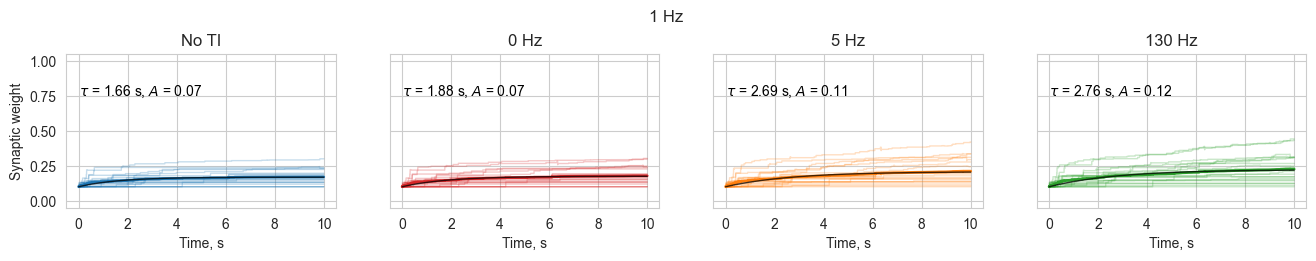

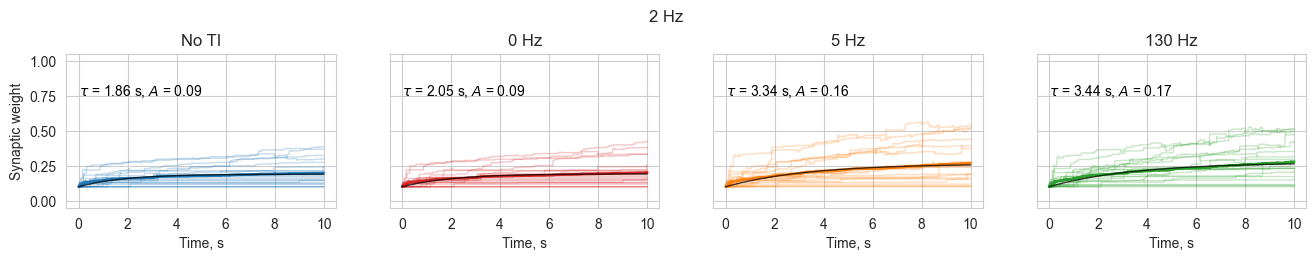

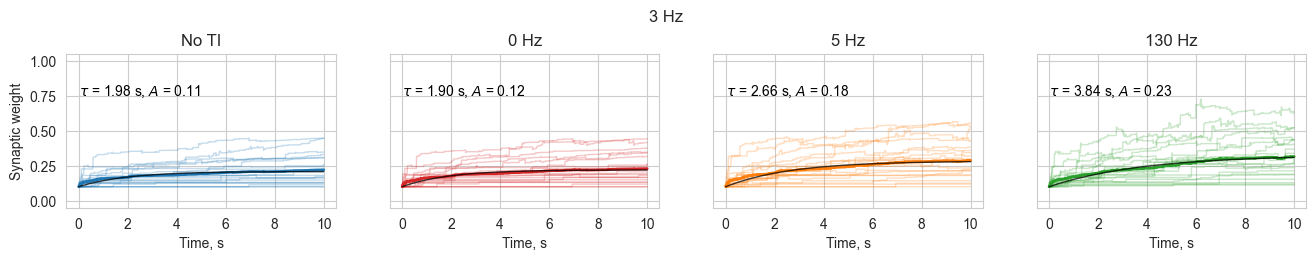

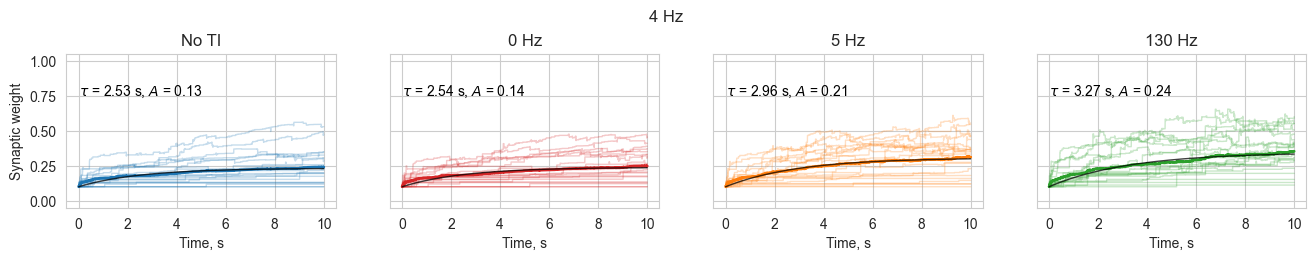

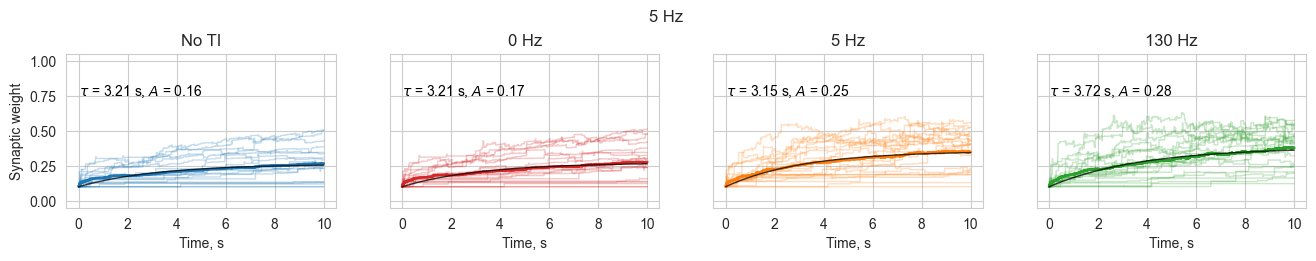

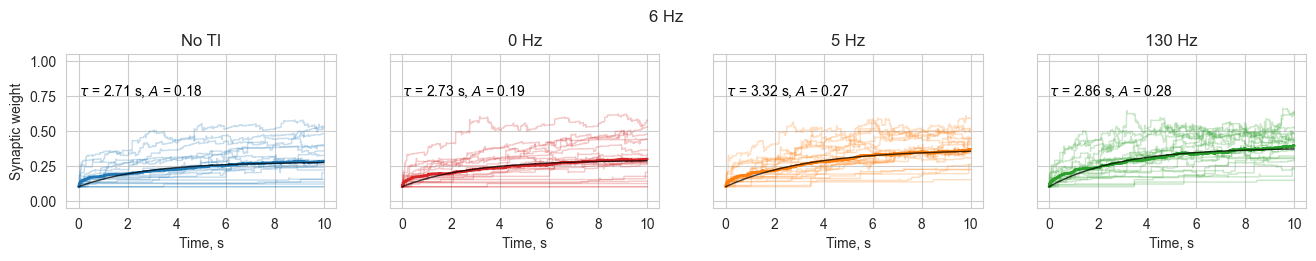

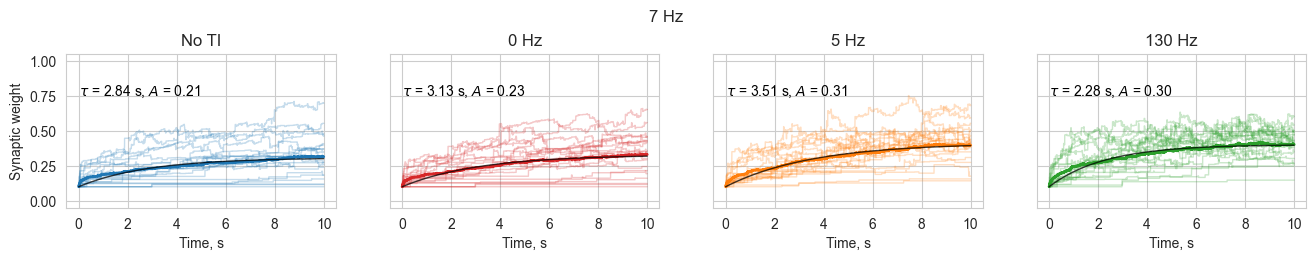

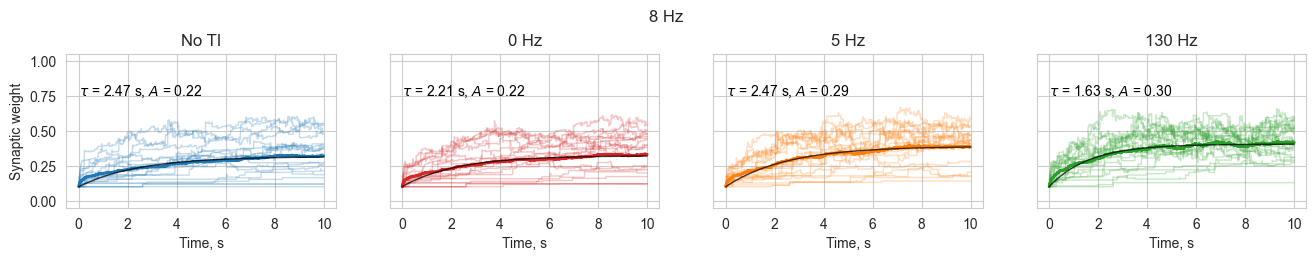

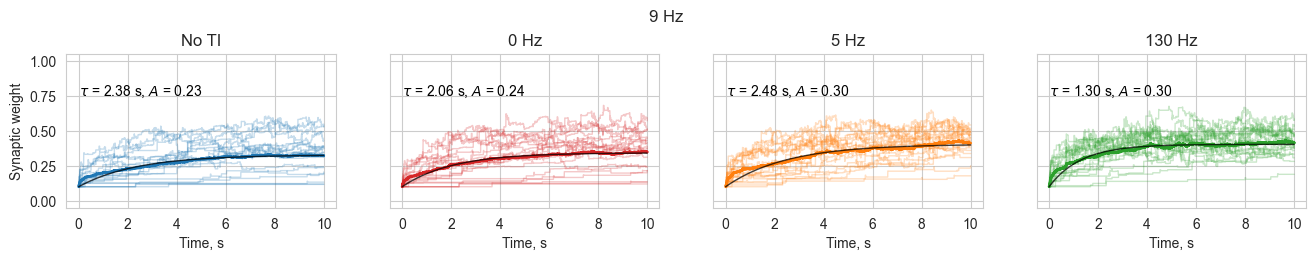

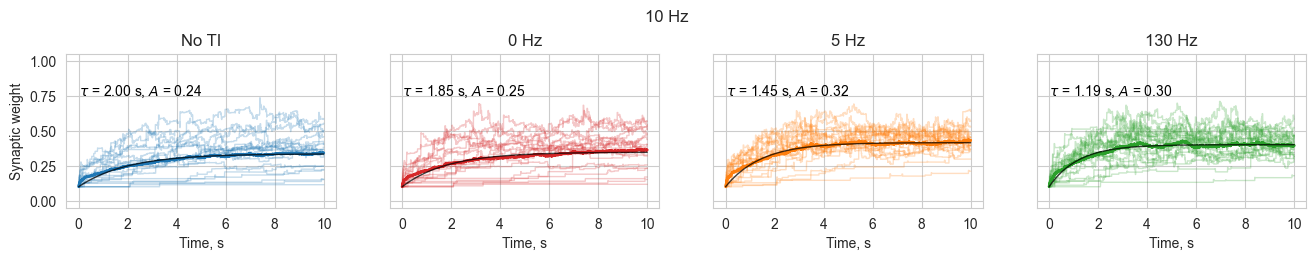

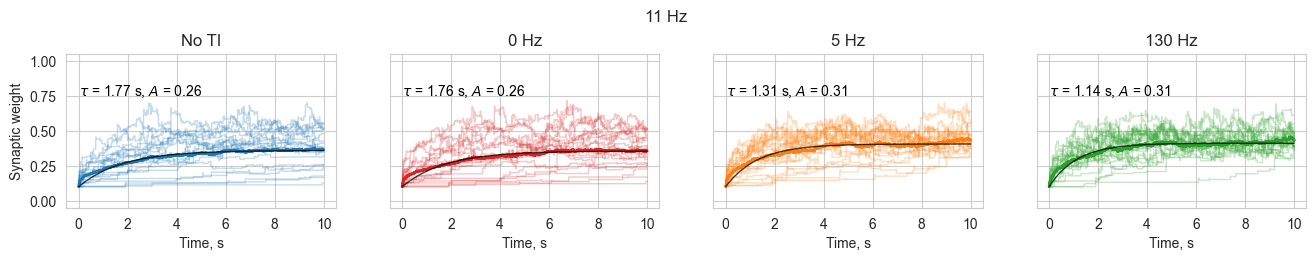

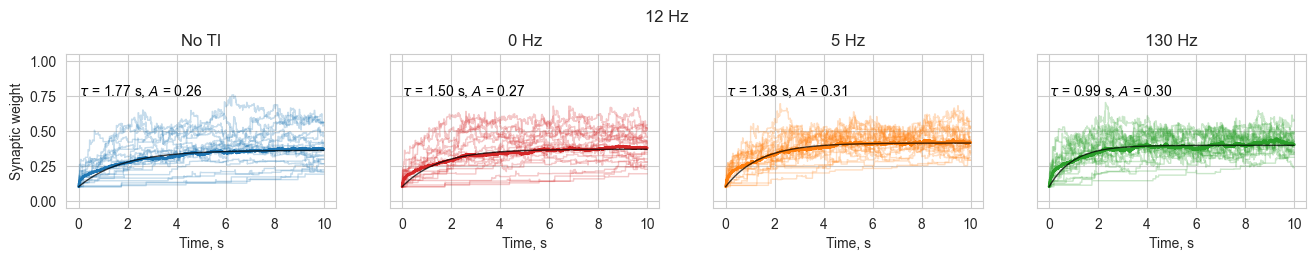

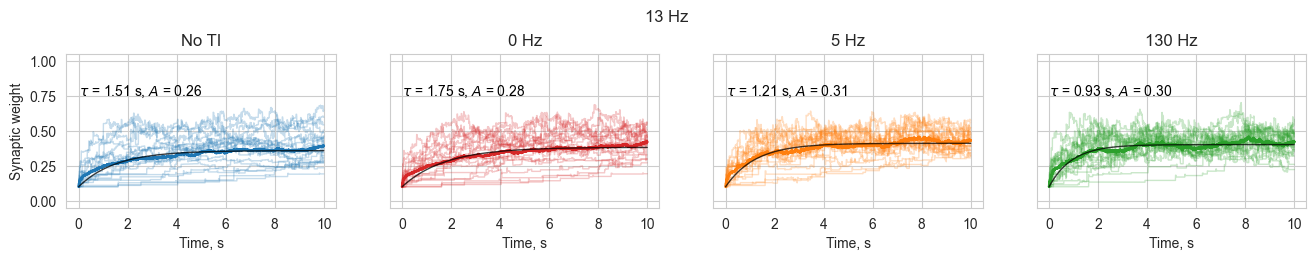

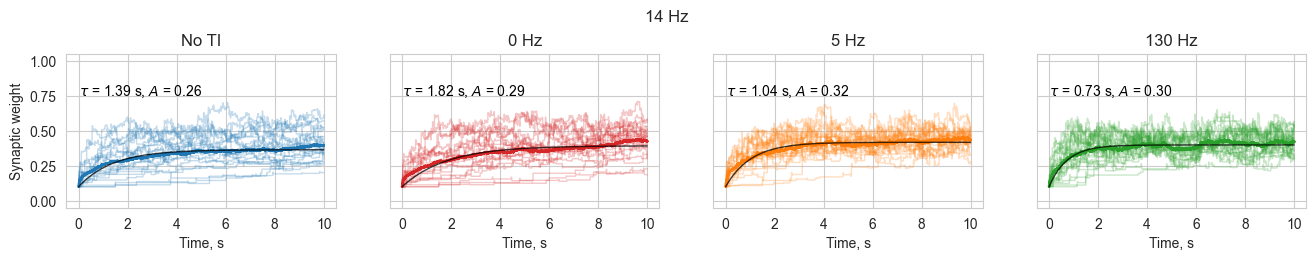

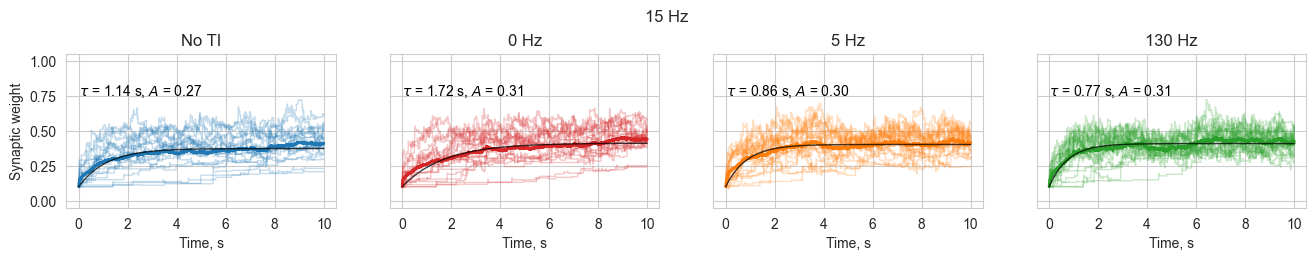

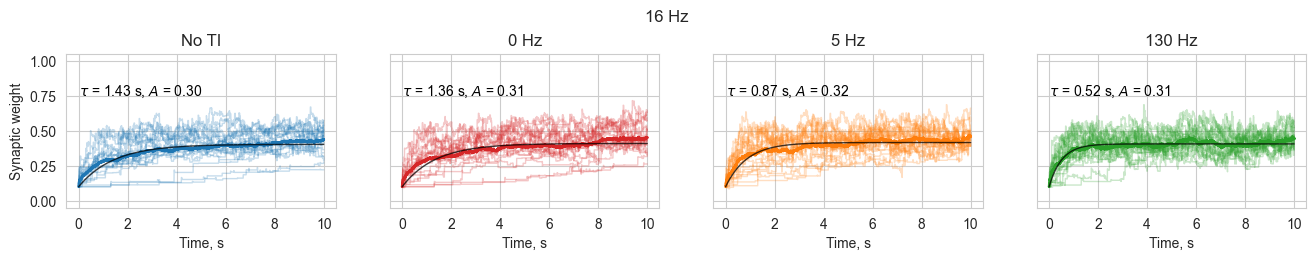

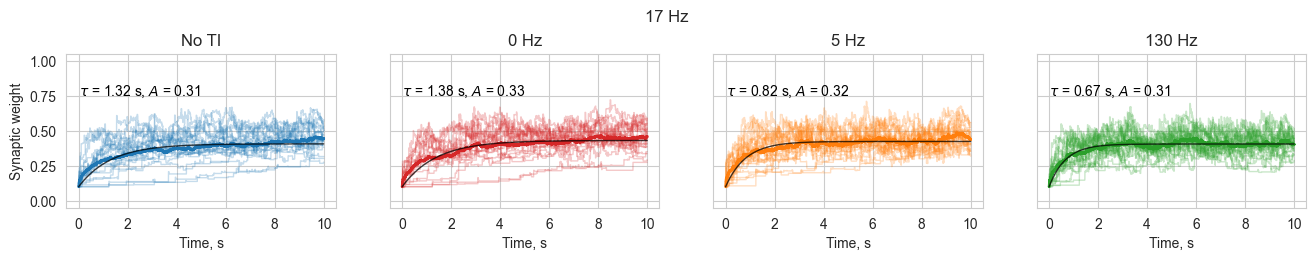

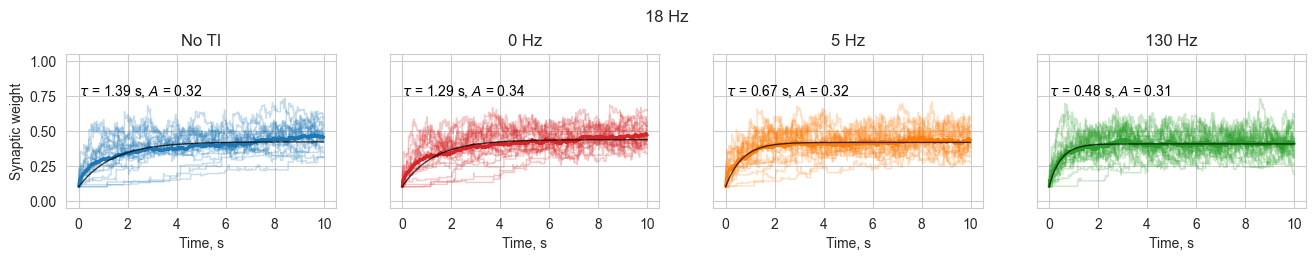

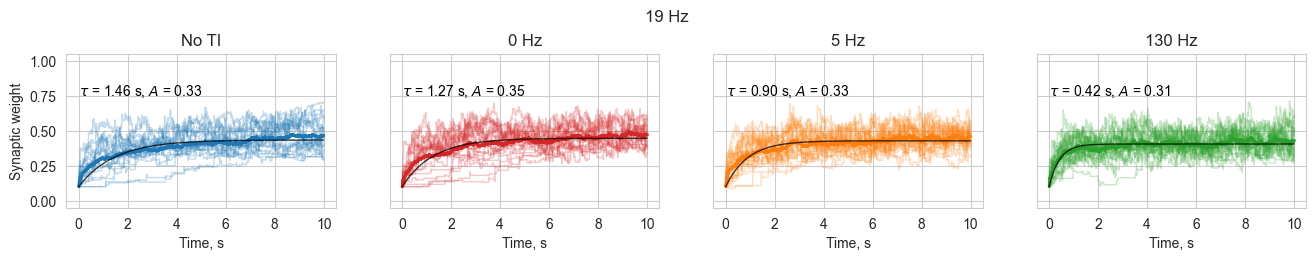

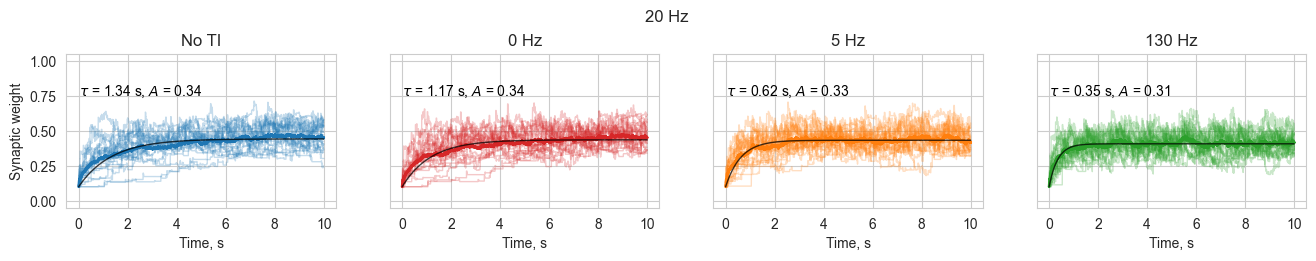

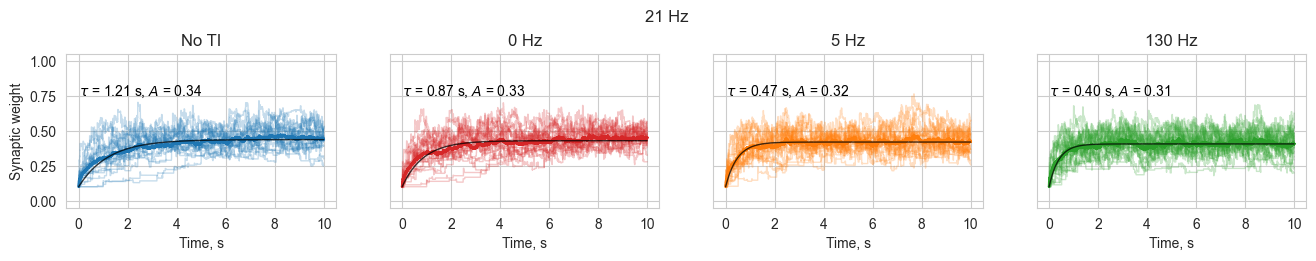

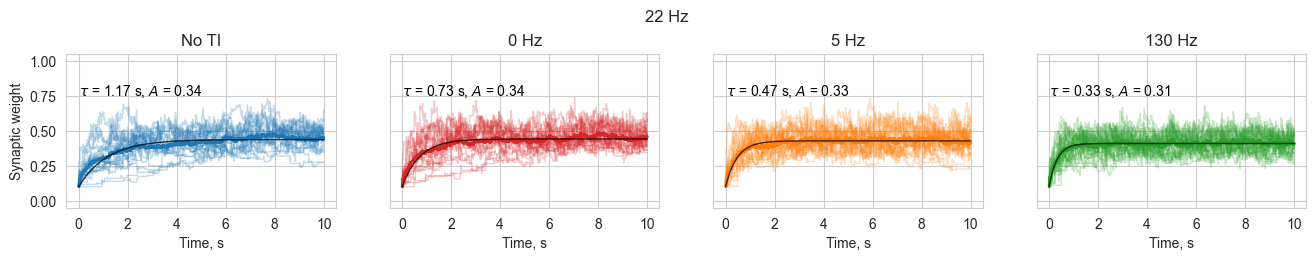

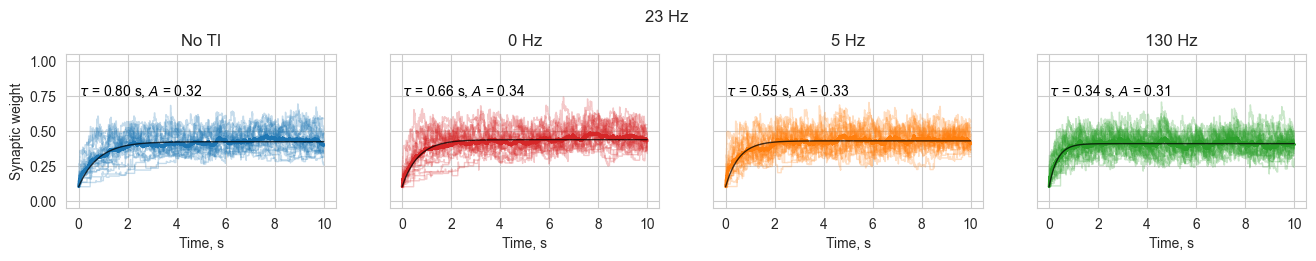

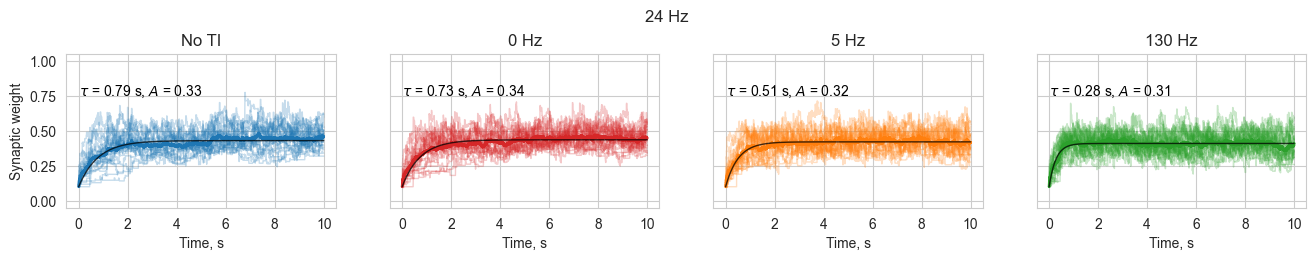

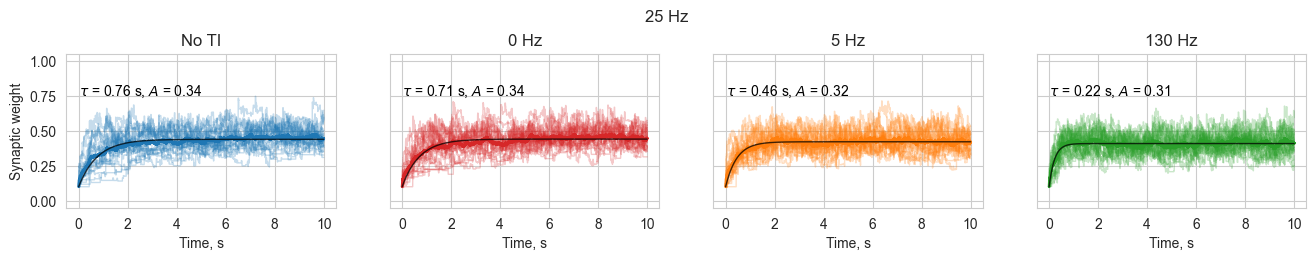

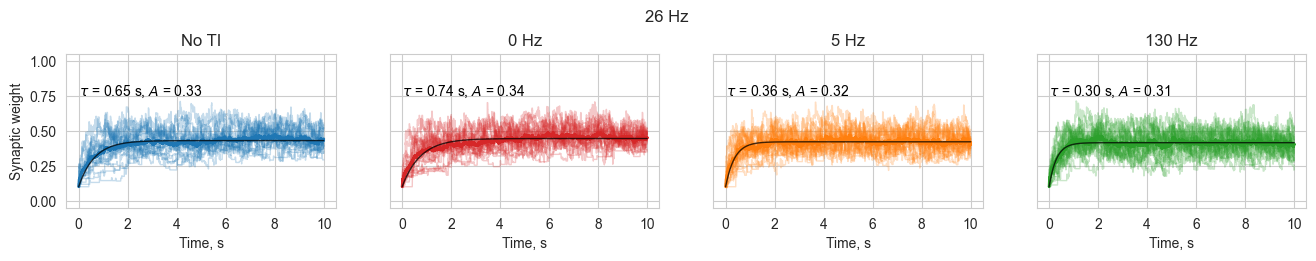

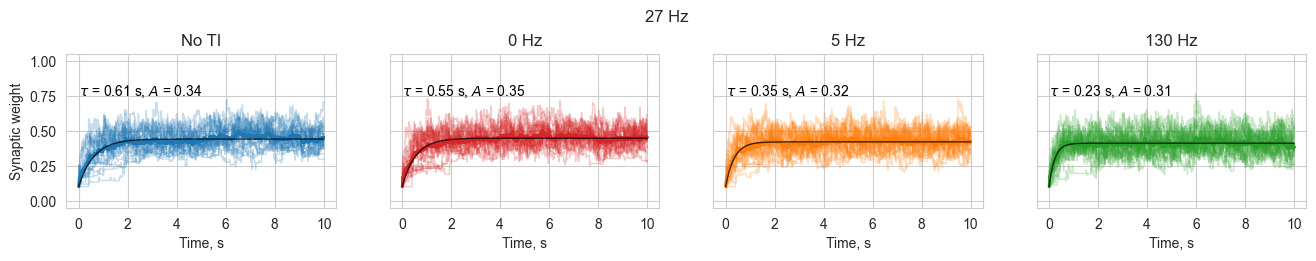

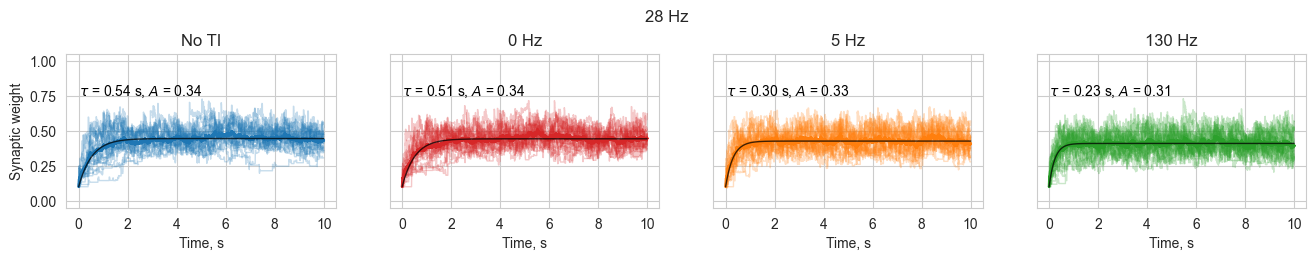

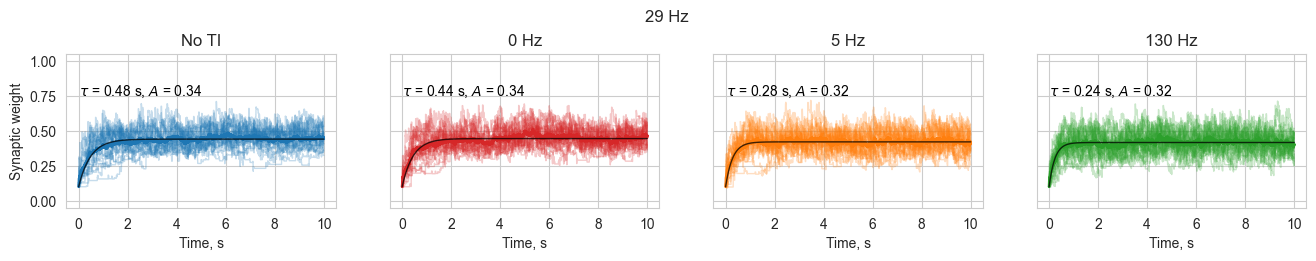

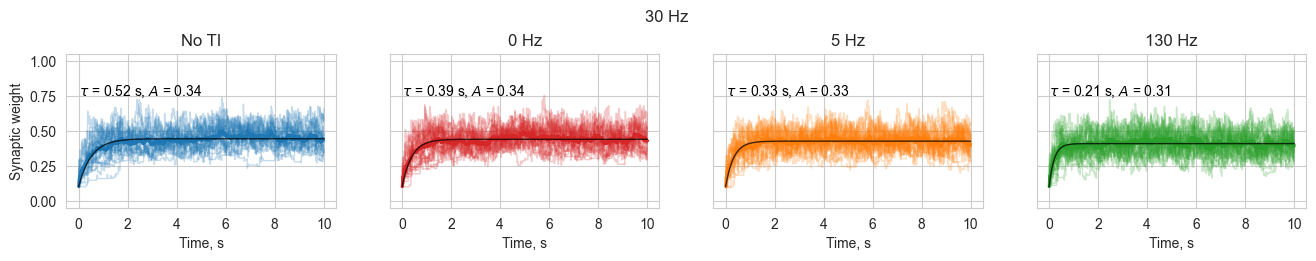

In [22]:
frequencies = np.arange(1, 31)

for frequency in frequencies:
    plot_weights(frequency)

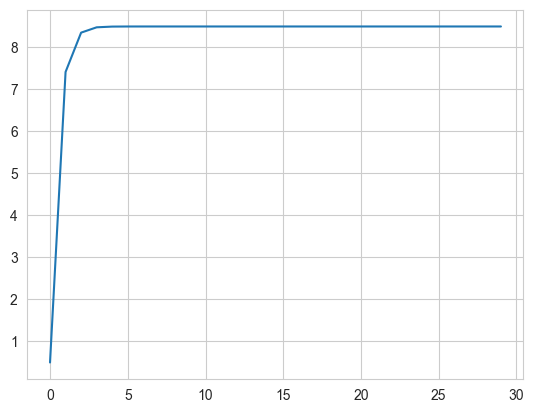

In [28]:
plt.plot(
    rising_exp(np.arange(0, 30), a1 = 8, tau1 = 0.5)
)